# Lecture 3. Accessing Financial Data via APIs

In [43]:
#!pip install yfinance

In [52]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the ticker
ticker = "AAPL"

# Download data using the more reliable history() method
stock = yf.Ticker(ticker)
data = stock.history(start="2020-01-01", end="2023-01-01", repair=True)

# Check what columns are available
print(f"Available columns: {data.columns.tolist()}")

# Use 'Close' from history() - it's already adjusted!
# If 'Adj Close' exists, use that instead
if 'Adj Close' in data.columns:
    prices = data['Adj Close']
else:
    prices = data['Close']  # history() returns adjusted close by default

Available columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Repaired?']


In [53]:
# Calculate returns
data['Returns'] = prices.pct_change()
data['Log_Returns'] = np.log(prices / prices.shift(1))

# Drop NaN values from return calculations
data_clean = data.dropna()

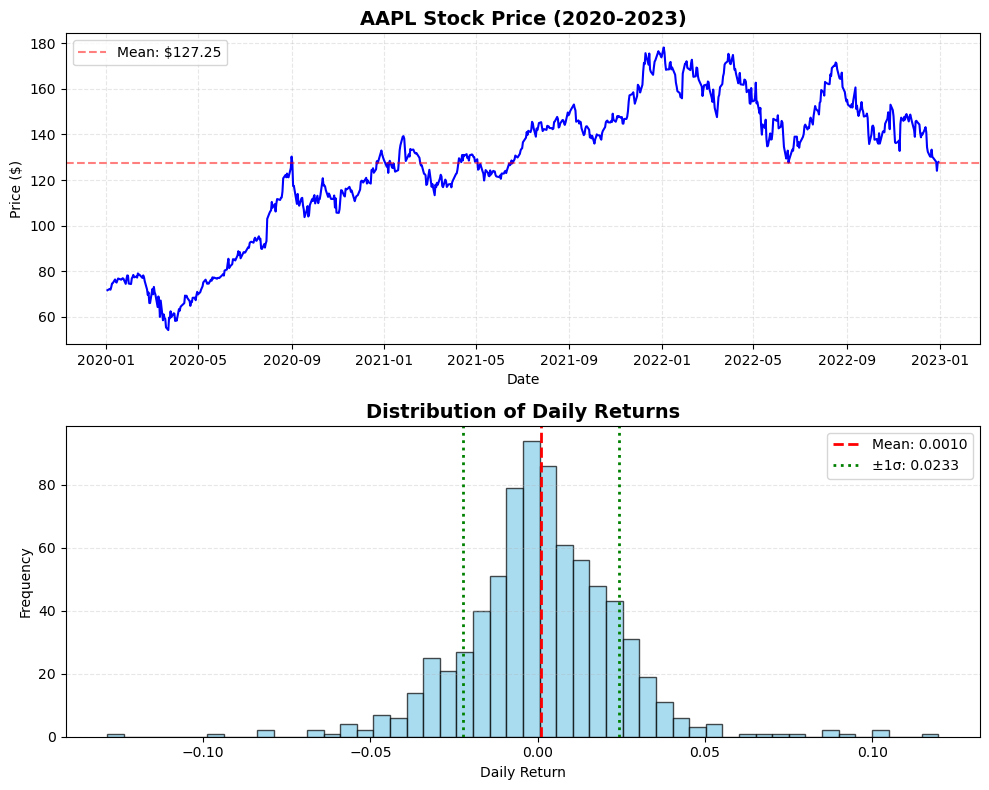

In [54]:
# =============== VISUALIZATION ===============
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot Price
ax[0].plot(data_clean.index, prices.loc[data_clean.index], linewidth=1.5, color='blue')
ax[0].set_title(f'{ticker} Stock Price (2020-2023)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Price ($)')
ax[0].grid(True, alpha=0.3, linestyle='--')
ax[0].axhline(y=prices.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: ${prices.mean():.2f}')
ax[0].legend()

# Plot Returns Distribution
ax[1].hist(data_clean['Returns'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax[1].set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Daily Return')
ax[1].set_ylabel('Frequency')
ax[1].grid(True, alpha=0.3, linestyle='--', axis='y')

# Add mean and standard deviation lines
mean_ret = data_clean['Returns'].mean()
std_ret = data_clean['Returns'].std()
ax[1].axvline(x=mean_ret, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ret:.4f}')
ax[1].axvline(x=mean_ret + std_ret, color='green', linestyle=':', linewidth=2, label=f'±1σ: {std_ret:.4f}')
ax[1].axvline(x=mean_ret - std_ret, color='green', linestyle=':', linewidth=2)
ax[1].legend()

plt.tight_layout()
plt.show()

In [55]:
# =============== PRINT STATISTICS ===============
print(f"\n=== {ticker} Statistics ===")
print(f"Date Range: {data_clean.index[0].date()} to {data_clean.index[-1].date()}")
print(f"Number of Trading Days: {len(data_clean)}")
print(f"Mean Daily Return: {mean_ret:.6f} ({mean_ret*100:.4f}%)")
print(f"Daily Volatility (Std): {std_ret:.6f} ({std_ret*100:.4f}%)")
print(f"Annualized Volatility: {std_ret * np.sqrt(252):.4f} ({std_ret * np.sqrt(252)*100:.2f}%)")
print(f"Min Return: {data_clean['Returns'].min():.4f} ({data_clean['Returns'].min()*100:.2f}%)")
print(f"Max Return: {data_clean['Returns'].max():.4f} ({data_clean['Returns'].max()*100:.2f}%)")


=== AAPL Statistics ===
Date Range: 2020-01-03 to 2022-12-30
Number of Trading Days: 755
Mean Daily Return: 0.001024 (0.1024%)
Daily Volatility (Std): 0.023266 (2.3266%)
Annualized Volatility: 0.3693 (36.93%)
Min Return: -0.1286 (-12.86%)
Max Return: 0.1198 (11.98%)


Columns available: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Repaired?', 'Returns', 'Log_Returns', 'Simple_Return', 'Log_Return']

=== AAPL Returns Comparison ===
Metric               Simple          Log            
--------------------------------------------------
Mean                 0.001024        0.000753       
Std                  0.023266        0.023255       
Min                  -0.128647       -0.137708      
Max                  0.119808        0.113157       


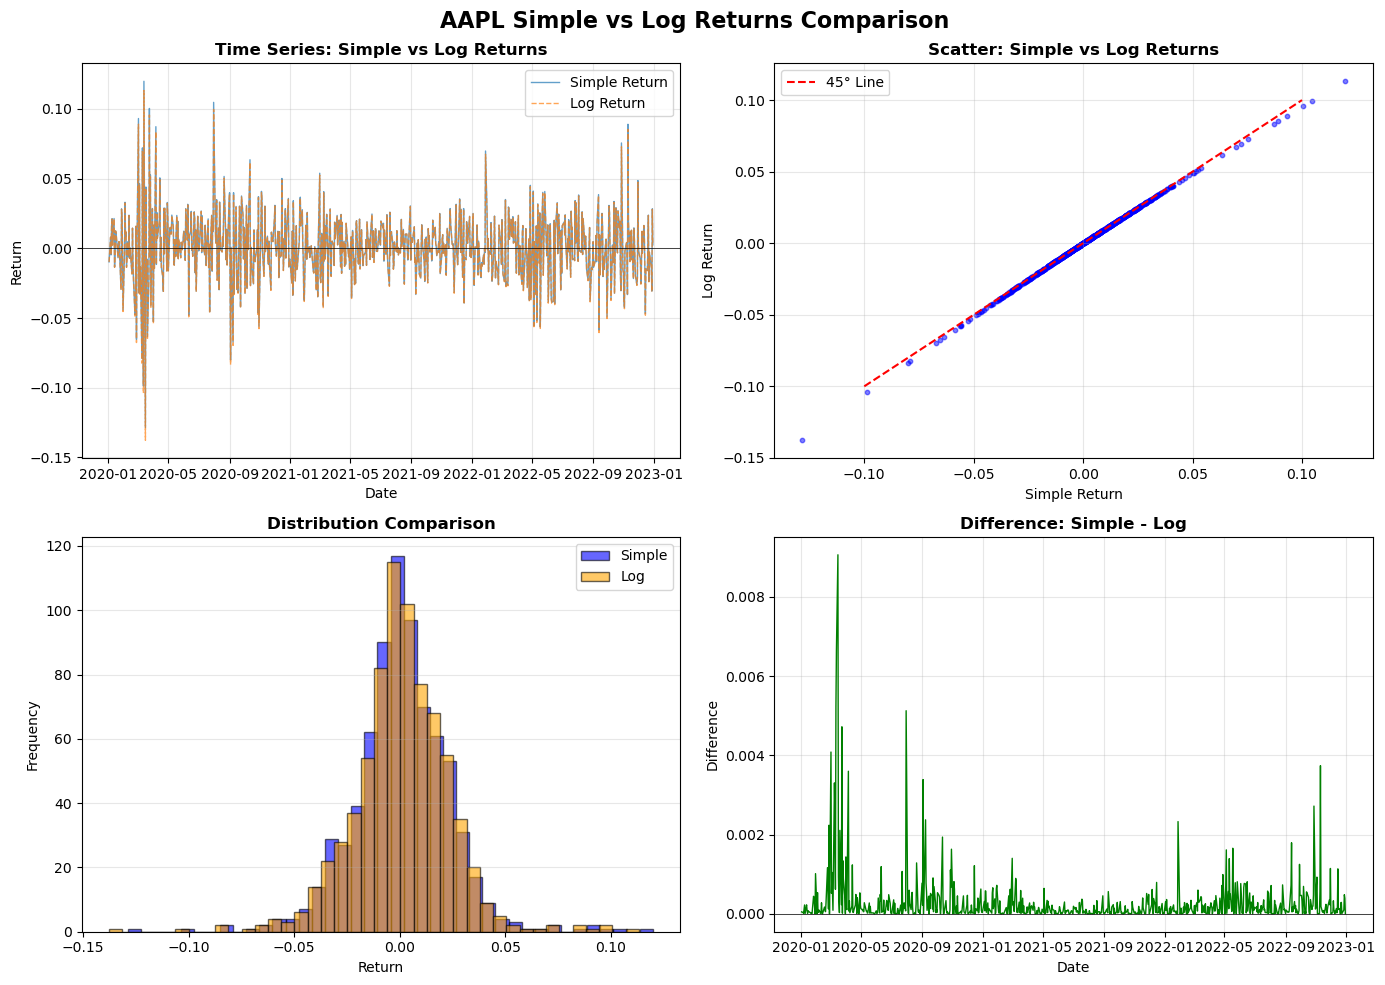

In [56]:
# =============== CALCULATE RETURNS ===============
data['Simple_Return'] = prices.pct_change()
data['Log_Return'] = np.log(prices / prices.shift(1))

# Drop NaN from first row
data_clean = data.dropna().copy()

# =============== VERIFY COLUMNS EXIST ===============
print(f"Columns available: {data_clean.columns.tolist()}")
assert 'Simple_Return' in data_clean.columns, "Simple_Return column missing!"
assert 'Log_Return' in data_clean.columns, "Log_Return column missing!"

# =============== PRINT STATISTICS ===============
print(f"\n=== {ticker} Returns Comparison ===")
print(f"{'Metric':<20} {'Simple':<15} {'Log':<15}")
print("-" * 50)
print(f"{'Mean':<20} {data_clean['Simple_Return'].mean():<15.6f} {data_clean['Log_Return'].mean():<15.6f}")
print(f"{'Std':<20} {data_clean['Simple_Return'].std():<15.6f} {data_clean['Log_Return'].std():<15.6f}")
print(f"{'Min':<20} {data_clean['Simple_Return'].min():<15.6f} {data_clean['Log_Return'].min():<15.6f}")
print(f"{'Max':<20} {data_clean['Simple_Return'].max():<15.6f} {data_clean['Log_Return'].max():<15.6f}")

# =============== VISUALIZATION ===============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{ticker} Simple vs Log Returns Comparison', fontsize=16, fontweight='bold')

# Plot 1: Time Series
axes[0, 0].plot(data_clean.index, data_clean['Simple_Return'], 
                label='Simple Return', alpha=0.7, linewidth=1)
axes[0, 0].plot(data_clean.index, data_clean['Log_Return'], 
                label='Log Return', alpha=0.7, linewidth=1, linestyle='--')
axes[0, 0].set_title('Time Series: Simple vs Log Returns', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Return')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Plot 2: Scatter Plot
axes[0, 1].scatter(data_clean['Simple_Return'], data_clean['Log_Return'], 
                   alpha=0.5, s=10, color='blue')
axes[0, 1].plot([-0.1, 0.1], [-0.1, 0.1], 'r--', label='45° Line')
axes[0, 1].set_title('Scatter: Simple vs Log Returns', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Simple Return')
axes[0, 1].set_ylabel('Log Return')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution
axes[1, 0].hist(data_clean['Simple_Return'], bins=40, alpha=0.6, 
                color='blue', label='Simple', edgecolor='black')
axes[1, 0].hist(data_clean['Log_Return'], bins=40, alpha=0.6, 
                color='orange', label='Log', edgecolor='black')
axes[1, 0].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Return')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Difference
difference = data_clean['Simple_Return'] - data_clean['Log_Return']
axes[1, 1].plot(data_clean.index, difference, color='green', linewidth=1)
axes[1, 1].set_title('Difference: Simple - Log', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Difference')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## Assignment

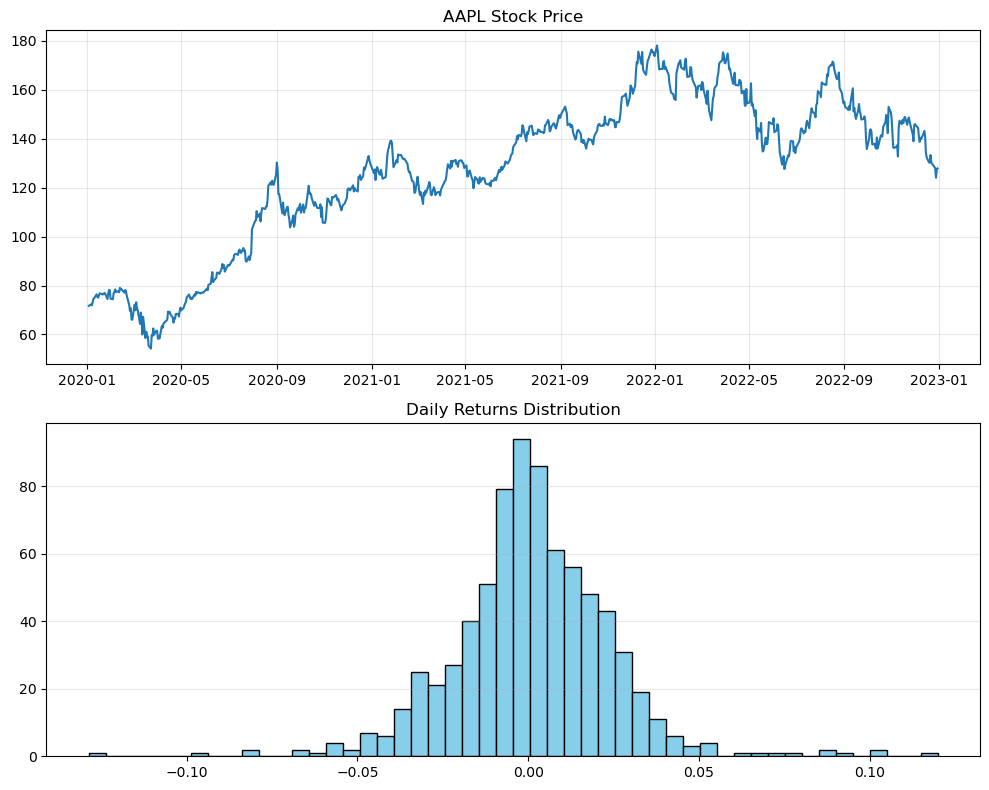

Mean Daily Return: 0.0010
Volatility (Daily): 0.0233
Volatility (Annual): 0.3693


In [57]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ticker = "AAPL"
stock = yf.Ticker(ticker)
data = stock.history(start="2020-01-01", end="2023-01-01", repair=True)

# Get prices (Close is already adjusted in history())
prices = data['Close']

# Calculate returns
data['Returns'] = prices.pct_change()
data = data.dropna()  # Remove NaN from first row

# Create the plot
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Price
ax[0].plot(data.index, data['Close'])
ax[0].set_title(f'{ticker} Stock Price')
ax[0].grid(True, alpha=0.3)

# Returns histogram
ax[1].hist(data['Returns'], bins=50, color='skyblue', edgecolor='black')
ax[1].set_title('Daily Returns Distribution')
ax[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print key stats
print(f"Mean Daily Return: {data['Returns'].mean():.4f}")
print(f"Volatility (Daily): {data['Returns'].std():.4f}")
print(f"Volatility (Annual): {data['Returns'].std() * np.sqrt(252):.4f}")

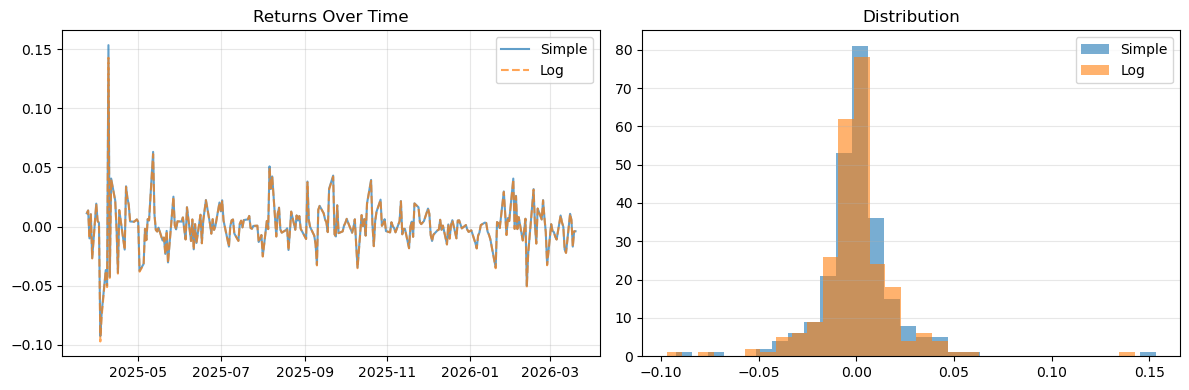

Mean Simple: 0.000725
Mean Log: 0.000528


In [58]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# Download
data = yf.Ticker("AAPL").history(period="1y", repair=True)

# Get prices
prices = data['Close']

# Calculate returns DIRECTLY (no column name issues)
simple_ret = prices.pct_change().dropna()
log_ret = np.log(prices / prices.shift(1)).dropna()

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(simple_ret.index, simple_ret, label='Simple', alpha=0.7)
ax[0].plot(log_ret.index, log_ret, label='Log', alpha=0.7, ls='--')
ax[0].set_title('Returns Over Time')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].hist(simple_ret, bins=30, alpha=0.6, label='Simple')
ax[1].hist(log_ret, bins=30, alpha=0.6, label='Log')
ax[1].set_title('Distribution')
ax[1].legend()
ax[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Mean Simple: {simple_ret.mean():.6f}")
print(f"Mean Log: {log_ret.mean():.6f}")